In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
import os

SUPPORTED_STOCKS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA"
]

RESULTS_DIR = "../results"
REPORTS_DIR = "../reports"

os.makedirs(RESULTS_DIR, exist_ok=True)

all_reports = []

MODEL EVALUATION : AAPL


,Ticker,Current Price,Predicted Price,Expected Change (%),Recommendation,Trading Score,Confidence (%),Average Sentiment,Trend,Overall Performance
0,AAPL,340.08,302.69,-10.99,SELL,-2.0,40.0,0.132,Bearish,Good


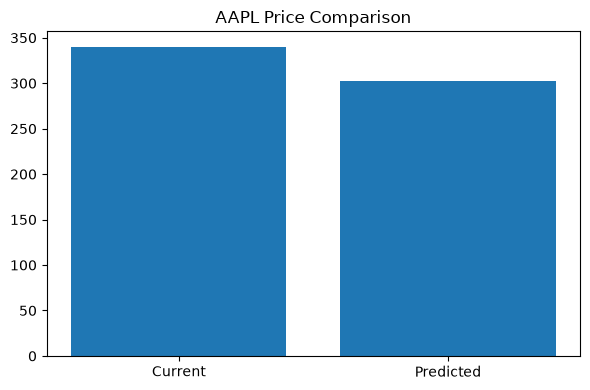


MODEL EVALUATION : MSFT


,Ticker,Current Price,Predicted Price,Expected Change (%),Recommendation,Trading Score,Confidence (%),Average Sentiment,Trend,Overall Performance
0,MSFT,393.35,520.93,32.43,HOLD,2.0,40.0,0.114,Bullish,Good


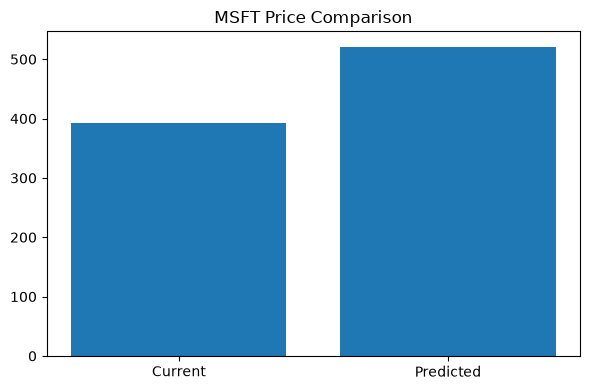


MODEL EVALUATION : GOOGL


,Ticker,Current Price,Predicted Price,Expected Change (%),Recommendation,Trading Score,Confidence (%),Average Sentiment,Trend,Overall Performance
0,GOOGL,333.71,333.44,-0.08,SELL,-4.0,80.0,0.143,Bearish,Excellent


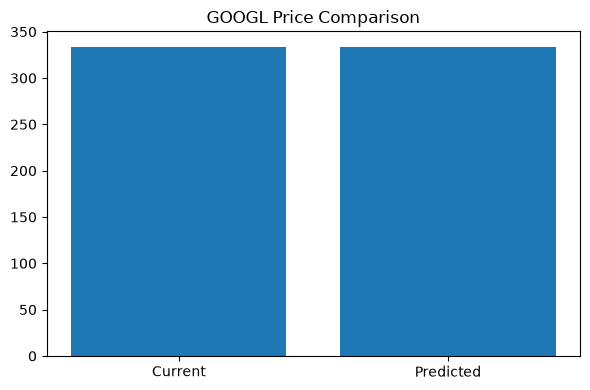


MODEL EVALUATION : AMZN


,Ticker,Current Price,Predicted Price,Expected Change (%),Recommendation,Trading Score,Confidence (%),Average Sentiment,Trend,Overall Performance
0,AMZN,230.86,246.3,6.69,HOLD,0.0,0.0,0.152,Bullish,Needs Improvement


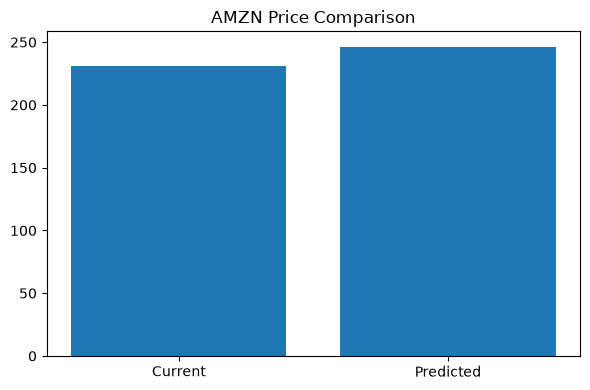


MODEL EVALUATION : NVDA


,Ticker,Current Price,Predicted Price,Expected Change (%),Recommendation,Trading Score,Confidence (%),Average Sentiment,Trend,Overall Performance
0,NVDA,197.01,203.17,3.13,HOLD,0.0,0.0,0.122,Bullish,Needs Improvement


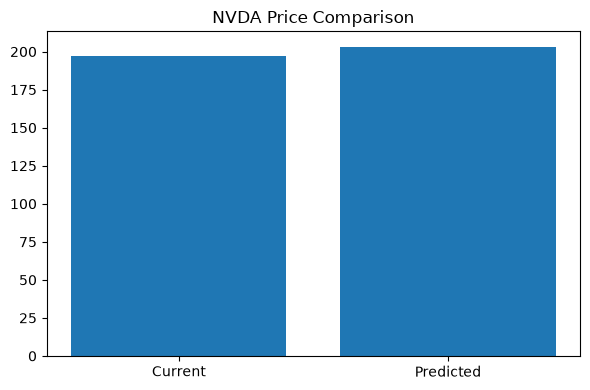

In [3]:
for ticker in SUPPORTED_STOCKS:

    print("=" * 70)
    print(f"MODEL EVALUATION : {ticker}")
    print("=" * 70)

    recommendation = pd.read_csv(
        f"{RESULTS_DIR}/{ticker}_recommendation.csv"
    )

    ai = pd.read_csv(
        f"{RESULTS_DIR}/{ticker}_ai_recommendation.csv"
    )

    forecast = pd.read_csv(
        f"{REPORTS_DIR}/{ticker}/prophet_forecast.csv"
    )

    current_price = float(recommendation.loc[0, "Current Price"])
    predicted_price = float(recommendation.loc[0, "Predicted Price"])

    trading_score = float(recommendation.loc[0, "Trading Score"])
    recommendation_text = recommendation.loc[0, "Recommendation"]

    confidence = float(ai.loc[0, "Confidence (%)"])
    sentiment = float(ai.loc[0, "Average Sentiment"])

    change_percent = (
        (predicted_price - current_price)
        / current_price
    ) * 100

    if predicted_price > current_price:
        trend = "Bullish"
    elif predicted_price < current_price:
        trend = "Bearish"
    else:
        trend = "Neutral"

    if confidence >= 80:
        performance = "Excellent"

    elif confidence >= 60:
        performance = "Very Good"

    elif confidence >= 40:
        performance = "Good"

    else:
        performance = "Needs Improvement"

    report = pd.DataFrame({

        "Ticker":[ticker],

        "Current Price":[round(current_price,2)],

        "Predicted Price":[round(predicted_price,2)],

        "Expected Change (%)":[round(change_percent,2)],

        "Recommendation":[recommendation_text],

        "Trading Score":[trading_score],

        "Confidence (%)":[confidence],

        "Average Sentiment":[sentiment],

        "Trend":[trend],

        "Overall Performance":[performance]

    })

    display(report)

    report.to_csv(

        f"{RESULTS_DIR}/{ticker}_model_evaluation.csv",

        index=False

    )

    all_reports.append(report)

    plt.figure(figsize=(6,4))

    plt.bar(
        ["Current","Predicted"],
        [current_price,predicted_price]
    )

    plt.title(f"{ticker} Price Comparison")

    plt.tight_layout()

    plt.show()

    print()

In [4]:
final_report = pd.concat(
    all_reports,
    ignore_index=True
)

final_report.to_csv(
    f"{RESULTS_DIR}/all_model_evaluation.csv",
    index=False
)

print("=" * 70)
print("LAB 13 COMPLETED SUCCESSFULLY")
print("=" * 70)

display(final_report)

LAB 13 COMPLETED SUCCESSFULLY


,Ticker,Current Price,Predicted Price,Expected Change (%),Recommendation,Trading Score,Confidence (%),Average Sentiment,Trend,Overall Performance
0,AAPL,340.08,302.69,-10.99,SELL,-2.0,40.0,0.132,Bearish,Good
1,MSFT,393.35,520.93,32.43,HOLD,2.0,40.0,0.114,Bullish,Good
2,GOOGL,333.71,333.44,-0.08,SELL,-4.0,80.0,0.143,Bearish,Excellent
3,AMZN,230.86,246.30,6.69,HOLD,0.0,0.0,0.152,Bullish,Needs Improvement
4,NVDA,197.01,203.17,3.13,HOLD,0.0,0.0,0.122,Bullish,Needs Improvement


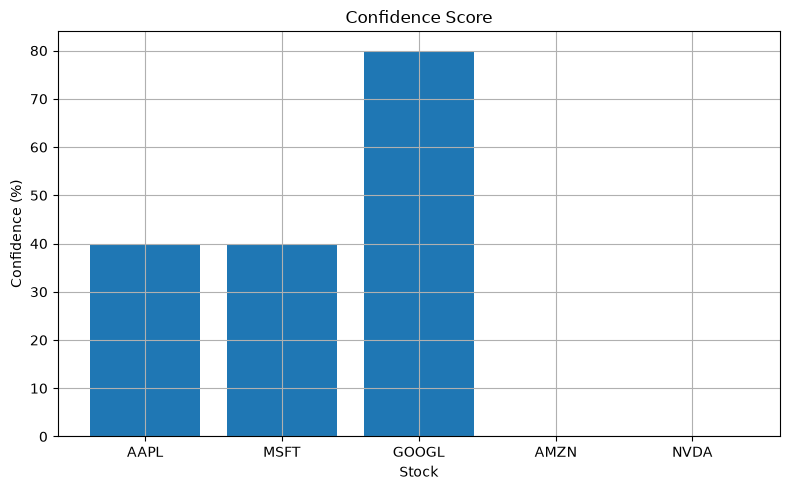

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    final_report["Ticker"],
    final_report["Confidence (%)"]
)

plt.title("Confidence Score")

plt.xlabel("Stock")

plt.ylabel("Confidence (%)")

plt.grid(True)

plt.tight_layout()

plt.show()

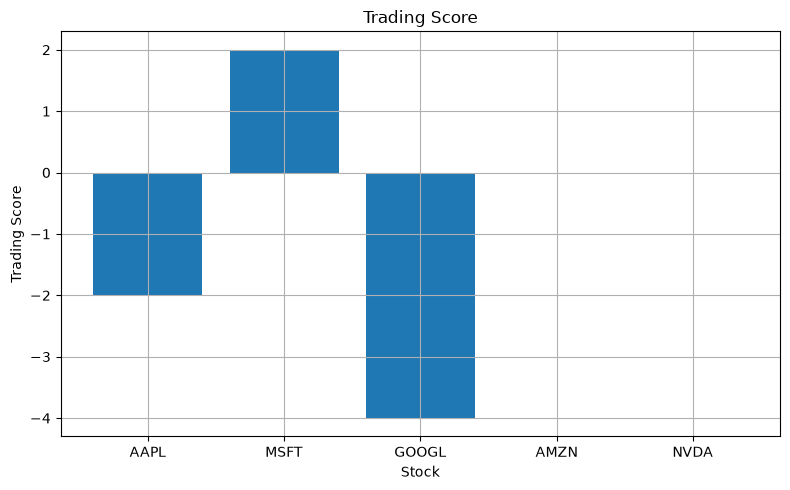

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    final_report["Ticker"],
    final_report["Trading Score"]
)

plt.title("Trading Score")

plt.xlabel("Stock")

plt.ylabel("Trading Score")

plt.grid(True)

plt.tight_layout()

plt.show()

In [7]:
ranking = final_report.sort_values(
    by="Confidence (%)",
    ascending=False
)

print("=" * 70)
print("MODEL RANKING")
print("=" * 70)

display(ranking)

MODEL RANKING


,Ticker,Current Price,Predicted Price,Expected Change (%),Recommendation,Trading Score,Confidence (%),Average Sentiment,Trend,Overall Performance
2,GOOGL,333.71,333.44,-0.08,SELL,-4.0,80.0,0.143,Bearish,Excellent
0,AAPL,340.08,302.69,-10.99,SELL,-2.0,40.0,0.132,Bearish,Good
1,MSFT,393.35,520.93,32.43,HOLD,2.0,40.0,0.114,Bullish,Good
3,AMZN,230.86,246.30,6.69,HOLD,0.0,0.0,0.152,Bullish,Needs Improvement
4,NVDA,197.01,203.17,3.13,HOLD,0.0,0.0,0.122,Bullish,Needs Improvement
